# Project 6 — Module 7: Aprendizaje de Máquina No Supervisado
## Lección 2 & 3: Data Understanding + Preprocessing Setup

| | |
|---|---|
| **Author** | Jose Marcel Lopez Pino |
| **Framework** | CRISP-DM + LEAN |
| **Phase** | 2 — Data Understanding |
| **Module** | 7 — Aprendizaje de Máquina No Supervisado (Alkemy Bootcamp) |
| **Dataset** | Customer Segmentation — Kaggle (kaushiksuresh147) |
| **Date** | 2026-03 |

---

> **Executive Summary:**
> This notebook explores the raw customer dataset to assess data quality, distributions, and
> feature relevance. The output is a documented data profile that directly informs preprocessing
> decisions in notebook 03. Only variables decision-relevant for behavioral segmentation are retained.

## Table of Contents

1. [CRISP-DM Phase 2 — Data Understanding](#1-crisp-dm-phase-2--data-understanding)
2. [Environment Setup](#2-environment-setup)
3. [Load Data](#3-load-data)
4. [Shape & Schema](#4-shape--schema)
5. [Missing Values Audit](#5-missing-values-audit)
6. [Univariate Distributions](#6-univariate-distributions)
7. [Bivariate Analysis (decision-relevant pairs)](#7-bivariate-analysis)
8. [Correlation Matrix](#8-correlation-matrix)
9. [LEAN Filter — Waste Elimination Review](#9-lean-filter--waste-elimination-review)
10. [Decisions Log — Lesson 2](#10-decisions-log--lesson-2)
11. [Next Steps — Lesson 3 Preview](#11-next-steps--lesson-3-preview)

## 1. CRISP-DM Phase 2 — Data Understanding

**Goal:** Assess data quality and identify which features carry behavioral signal for clustering.
Apply LEAN principle: only explore what informs the segmentation decision.

> **Note:** Exploratory analysis of this dataset is available on the Kaggle dataset page:  
> https://www.kaggle.com/datasets/kaushiksuresh147/customer-segmentation  
> Basic distributions, variable descriptions, and summary statistics are documented there.  
> This notebook focuses on decision-relevant analysis for the segmentation pipeline only —
> following the LEAN principle of avoiding redundant exploration.
>
> **Dataset context:** Labels A/B/C/D were assigned manually by the automobile company's
> sales team — not derived from clustering. Our unsupervised approach discovers natural
> structure independently. Labels are used only for external validation in notebook 05.

## 2. Environment Setup

In [1]:
# ===== Environment Setup =====
import warnings
warnings.formatwarning = lambda msg, *args, **kwargs: f'Warning: {msg}\n'
warnings.simplefilter('always')

# Python utilities
from pathlib import Path

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_d')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_RAW        = Path('../data/raw')
DATA_PROCESSED  = Path('../data/processed')
REPORTS_FIGURES = Path('../reports/figures')
REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)

print('Environment ready.')
print(f'Data path   : {DATA_RAW}')
print(f'Figures path: {REPORTS_FIGURES}')

Environment ready.
Data path   : ..\data\raw
Figures path: ..\reports\figures


## 3. Load Data

In [2]:
# Load raw dataset — no transformations at this stage
df = pd.read_csv(DATA_RAW / 'Train.csv')
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')
df.head()

Rows: 8,068 | Columns: 11


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


## 4. Shape & Schema

In [3]:
# Data types and unique counts
schema = pd.DataFrame({
    'dtype': df.dtypes,
    'n_unique': df.nunique(),
    'sample_values': [df[c].unique()[:5].tolist() for c in df.columns]
})
print(schema.to_string())

                   dtype  n_unique                                          sample_values
ID                 int64      8068               [462809, 462643, 466315, 461735, 462669]
Gender               str         2                                         [Male, Female]
Ever_Married         str         2                                         [No, Yes, nan]
Age                int64        67                                   [22, 38, 67, 40, 56]
Graduated            str         2                                         [No, Yes, nan]
Profession           str         9  [Healthcare, Engineer, Lawyer, Entertainment, Artist]
Work_Experience  float64        15                              [1.0, nan, 0.0, 4.0, 9.0]
Spending_Score       str         3                                   [Low, Average, High]
Family_Size      float64         9                              [4.0, 3.0, 1.0, 2.0, 6.0]
Var_1                str         7                    [Cat_4, Cat_6, Cat_7, Cat_3, Cat_1]
Segmentati

## 5. Missing Values Audit

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_report = missing_report[missing_report['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print('Columns with missing values:')
print(missing_report)

Columns with missing values:
                 missing_count  missing_pct
Work_Experience            829        10.28
Family_Size                335         4.15
Ever_Married               140         1.74
Profession                 124         1.54
Graduated                   78         0.97
Var_1                       76         0.94


## 6. Univariate Distributions

**LEAN filter applied:** Only plotting variables that contribute to behavioral profiling.

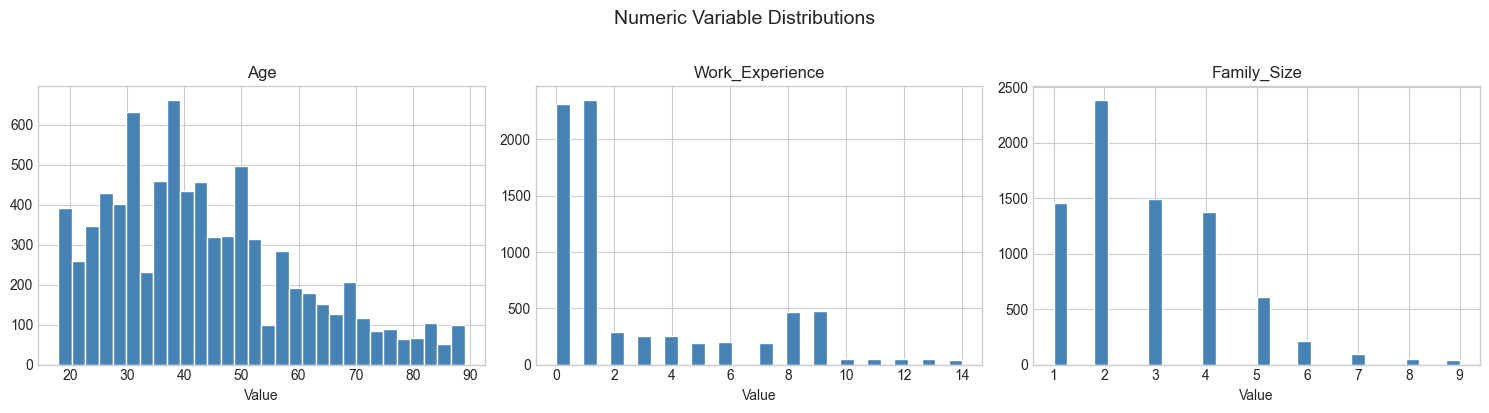

In [5]:
# Numeric variables
numeric_cols = df.select_dtypes(include='number').columns.drop('ID', errors='ignore').tolist()

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5 * len(numeric_cols), 4))
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
plt.suptitle('Numeric Variable Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / 'numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.


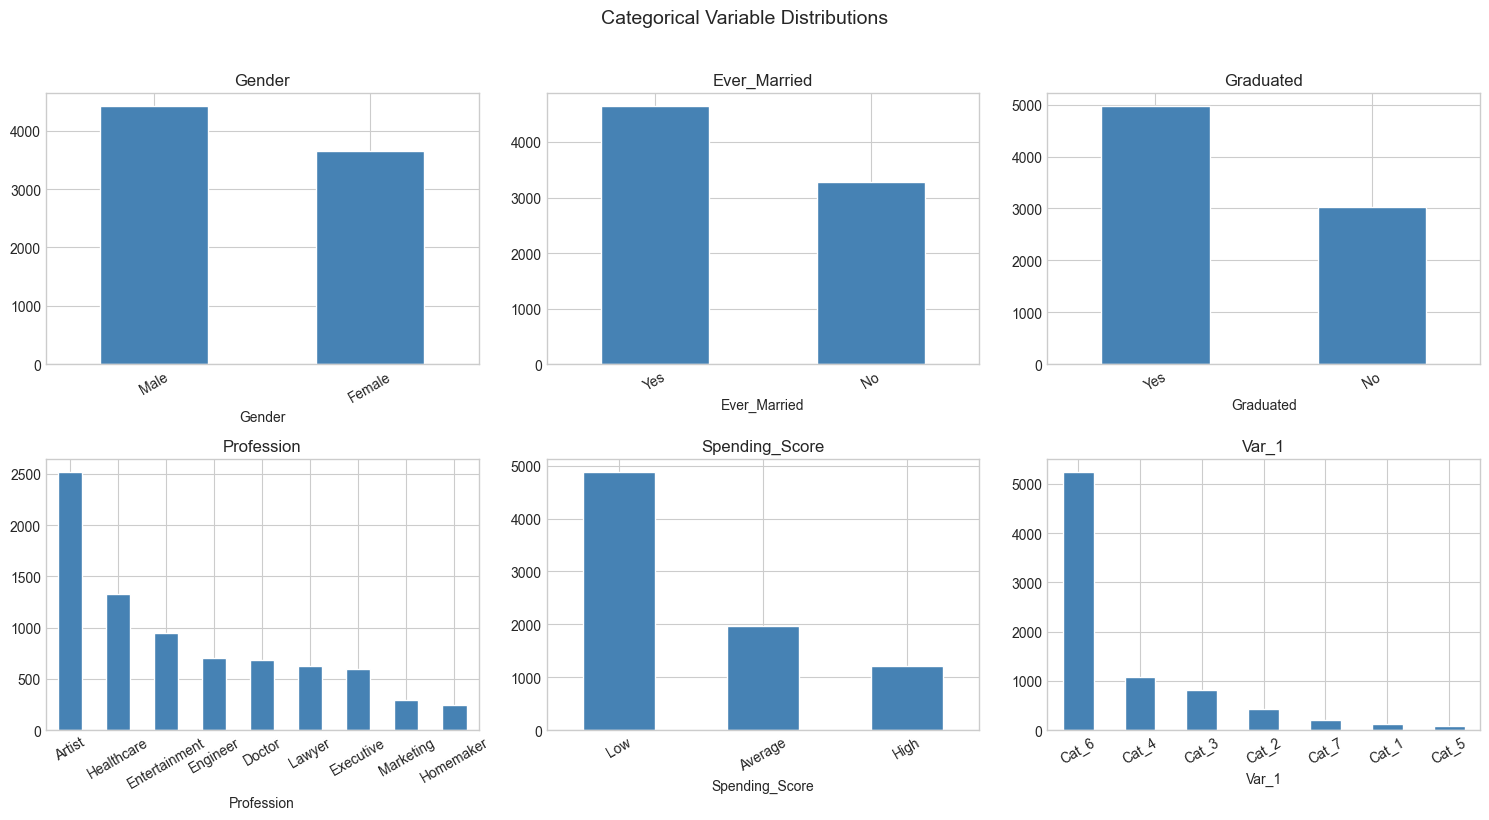

In [6]:
# Categorical variables
cat_cols = df.select_dtypes(include='object').columns.drop('Segmentation', errors='ignore').tolist()

fig, axes = plt.subplots(2, (len(cat_cols) + 1) // 2, figsize=(5 * ((len(cat_cols) + 1) // 2), 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Categorical Variable Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / 'categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Bivariate Analysis

Exploring decision-relevant relationships: spending behavior vs age, profession vs spending score.

In [7]:
# Cross-tabs for categorical pairs
if 'Spending_Score' in df.columns and 'Profession' in df.columns:
    ct = pd.crosstab(df['Profession'], df['Spending_Score'])
    ct_pct = ct.div(ct.sum(axis=1), axis=0).round(3)
    print('Spending Score by Profession (row %):'); print(ct_pct)

Spending Score by Profession (row %):
Spending_Score  Average   High    Low
Profession                           
Artist            0.402  0.096  0.502
Doctor            0.257  0.045  0.698
Engineer          0.316  0.086  0.598
Entertainment     0.336  0.048  0.615
Executive         0.125  0.664  0.210
Healthcare        0.032  0.034  0.935
Homemaker         0.244  0.106  0.650
Lawyer            0.029  0.520  0.451
Marketing         0.058  0.113  0.829


## 8. Correlation Matrix

Heatmap of pairwise correlations between numeric features.
Decision-relevant: identifies multicollinearity before encoding
and informs which features carry independent behavioral signal for clustering.

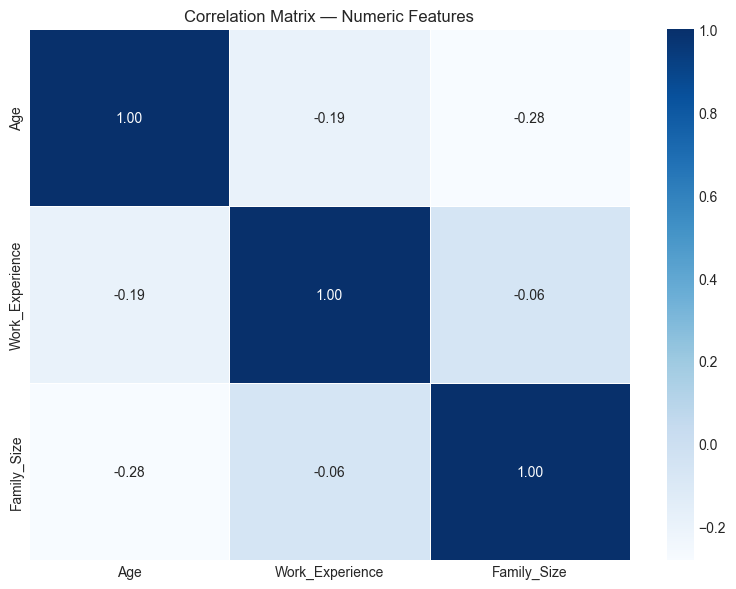

In [8]:
# Correlation matrix — numeric features only
numeric_cols = df.select_dtypes(include='number').columns.drop('ID', errors='ignore').tolist()
corr_matrix  = df[numeric_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / 'correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. LEAN Filter — Waste Elimination Review

| LEAN Question | Answer | Action |
|---------------|--------|--------|
| Does every analysis link to a business decision? | ✅ Distributions inform encoding + outlier strategy | Proceed |
| Is there redundancy between sections? | ✅ No | Proceed |
| Is n sufficient for planned clustering? | ✅ Check after loading | Proceed if n > 1,000 |
| Is there a simpler way to answer? | ⚠️ Could skip bivariate | Keep: informs feature selection |

## 10. Decisions Log — Lesson 2

| # | Decision | Rationale | Alternatives Considered | LEAN Value? |
|---|----------|-----------|------------------------|-------------|
| 1 | Drop `ID` column | Non-informative for clustering | Keep as index | ✅ |
| 2 | Hold `Segmentation` column out | Unsupervised discipline — discover natural segments, not reproduce known ones | Use as feature | ✅ |
| 3 | Focus bivariate on Spending_Score | Directly linked to campaign design decision | Exhaustive pair plots | ✅ |
| 4 | Generate test set via 80/20 split from Train.csv | Reproducible, controlled split — Kaggle's Test.csv lacks `Segmentation` column and is not version-controlled | Use Kaggle Test.csv | ✅ |
| 5 | Reference Kaggle page for basic EDA | Avoids duplicating publicly available analysis — LEAN waste elimination | Reproduce full EDA here | ✅ |

## 11. Next Steps — Lesson 3 Preview

- Encode categoricals (label, ordinal, one-hot per data dictionary strategy)
- Remove outliers with IQR (numeric columns)
- Standardize with `StandardScaler`
- Save `data/processed/customers_clean.csv`

---

**← Previous:** [01 — Business Understanding](./01_business_understanding.ipynb)  
**Next →** [03 — Data Preparation](./03_data_preparation.ipynb)